# Lecture 13: Bayesian Forecasting via MCMC

This notebook provides a minimal example of Bayesian prediction (forecasting) using Markov Chain Monte Carlo (MCMC).

We estimate a simple time-trend model with Gibbs sampling and then generate posterior predictive forecasts.

## 1. Model

For time index $t=1,\ldots,n$:
$$
y_t = \beta_0 + \beta_1 t + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2).
$$

Write in matrix form: $y = X\beta + \varepsilon$.

Priors (in hierarchical form):
$$
\beta \mid \sigma^2 \sim \mathcal{N}(b_0,\sigma^2 B_0),
\qquad
\sigma^2 \sim \text{Inv-Gamma}(a_0,d_0).
$$

The Gibbs sampler alternates:
1. Draw $\beta \mid \sigma^2, y$
2. Draw $\sigma^2 \mid \beta, y$

For forecasting horizon $h$, posterior predictive draws are
$$
\tilde y_{n+j}^{(m)} \sim \mathcal{N}(x_{n+j}'\beta^{(m)},\sigma^{2,(m)}), \quad j=1,\ldots,h.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

In [2]:
# Simulate a small time series and keep a holdout block for forecast evaluation.
n_train = 80
h = 12

beta_true = np.array([1.0, 0.08])
sigma_true = 0.6

t_all = np.arange(1, n_train + h + 1)
y_all = beta_true[0] + beta_true[1] * t_all + np.random.normal(0, sigma_true, size=t_all.size)

y_train = y_all[:n_train]
y_test = y_all[n_train:]

X_train = np.column_stack([np.ones(n_train), np.arange(1, n_train + 1)])

## 2. Gibbs sampler

This is MCMC because we generate a Markov chain of parameter draws from full conditionals.

In [ ]:
def gibbs_linear_regression(X, y, n_iter=6000, burn_in=1000):
    n, k = X.shape

    # prior
    b0 = np.zeros(k)
    B0 = 100.0 * np.eye(k)
    B0_inv = np.linalg.inv(B0)
    a0, d0 = 2.0, 1.0

    XtX = X.T @ X
    Xty = X.T @ y

    beta = np.zeros(k)
    sigma2 = 1.0

    beta_draws = []
    sigma2_draws = []

    for it in range(n_iter):
        # beta | sigma2, y ~ N(bn, sigma2 * Bn)
        Bn = np.linalg.inv(B0_inv + XtX)
        bn = Bn @ (B0_inv @ b0 + Xty)
        beta = np.random.multivariate_normal(mean=bn, cov=sigma2 * Bn)

        # sigma2 | beta, y ~ Inv-Gamma(an, dn)
        resid = y - X @ beta
        an = a0 + n / 2.0
        dn = d0 + 0.5 * (resid @ resid + (beta - b0).T @ B0_inv @ (beta - b0))
        sigma2 = 1.0 / np.random.gamma(shape=an, scale=1.0 / dn)

        if it >= burn_in:
            beta_draws.append(beta.copy())
            sigma2_draws.append(sigma2)

    return np.array(beta_draws), np.array(sigma2_draws)


beta_draws, sigma2_draws = gibbs_linear_regression(X_train, y_train)
print("Posterior draws:", beta_draws.shape[0])
print("Posterior mean beta:", beta_draws.mean(axis=0))
print("Posterior mean sigma:", np.sqrt(sigma2_draws.mean()))

Posterior draws: 5000
Posterior mean beta: [1.00432636 0.08009083]
Posterior mean sigma: 0.7053860070279527


In [4]:
# Posterior predictive forecast for periods n+1,...,n+h.
t_future = np.arange(n_train + 1, n_train + h + 1)
X_future = np.column_stack([np.ones(h), t_future])

m = beta_draws.shape[0]
pred_draws = np.zeros((m, h))

for i in range(m):
    pred_mean = X_future @ beta_draws[i]
    pred_draws[i] = np.random.normal(loc=pred_mean, scale=np.sqrt(sigma2_draws[i]))

forecast_mean = pred_draws.mean(axis=0)
forecast_p05 = np.quantile(pred_draws, 0.05, axis=0)
forecast_p95 = np.quantile(pred_draws, 0.95, axis=0)

print("First 3 forecast means:", np.round(forecast_mean[:3], 3))

First 3 forecast means: [7.487 7.569 7.632]


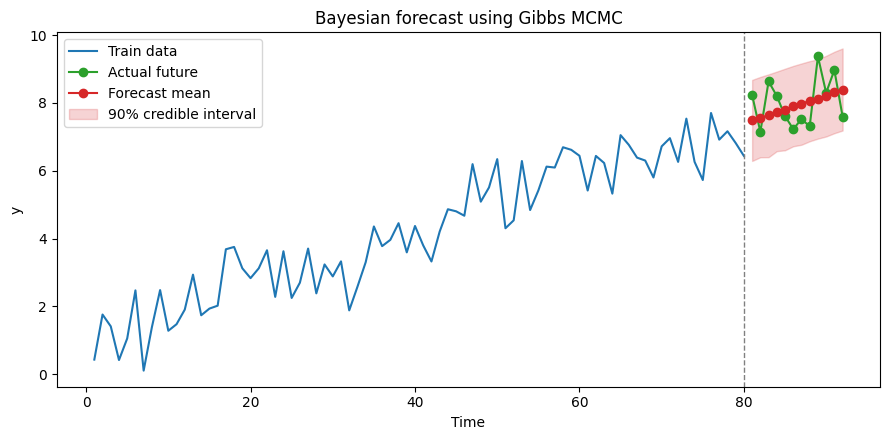

In [5]:
plt.figure(figsize=(9, 4.5))

t_train = np.arange(1, n_train + 1)
plt.plot(t_train, y_train, label="Train data", color="tab:blue")
plt.plot(t_future, y_test, "o-", label="Actual future", color="tab:green")
plt.plot(t_future, forecast_mean, "o-", label="Forecast mean", color="tab:red")
plt.fill_between(t_future, forecast_p05, forecast_p95, color="tab:red", alpha=0.2, label="90% credible interval")

plt.axvline(n_train, color="gray", linestyle="--", linewidth=1)
plt.title("Bayesian forecast using Gibbs MCMC")
plt.xlabel("Time")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Interpretation

- The red line is the posterior predictive mean forecast.
- The shaded area is the 90% posterior predictive interval (parameter uncertainty + shock uncertainty).
- This is a full Bayesian forecast because prediction integrates over posterior uncertainty via MCMC draws.